# 10 — Market Regime Detection

## Concept
OB strategies work best in TRENDING markets with clear structure.
In RANGING (choppy) markets, OBs are frequently:
- Violated and re-tested multiple times → stop-outs
- Never displaced from (no clean breakout)
- Formed in both directions simultaneously (no bias)

## Detection Method
**ADX (Average Directional Index)**:
- ADX ≥ 25 = trending (take OB signals)
- ADX ≤ 20 = ranging (pause OB trading)

**ATR Percentile**:
- ATR > 75th percentile = high volatility (reduce size)
- ATR < 25th percentile = low volatility (check geometry)

## Hypothesis
Skipping OB signals when ADX < 20 should:
- Dramatically reduce losses in choppy periods
- Maintain performance in trending periods
- Improve Sharpe ratio (less drawdown, similar upside)

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from strategy.ob_core import add_candle_features
from strategy.regime.market_regime import (
    detect_regime, add_regime_columns, MarketRegime
)
from strategy.ob_signals import list_ob_signals_enhanced, OBSignalConfig, get_passed_signals

plt.style.use('dark_background')
plt.rcParams.update({'figure.figsize': (18, 6)})

SYMBOL = 'XAUUSDT'
RISK   = 20.0

m5 = pd.read_csv(f'../notebooks/data/{SYMBOL}/M5/ohlcv.csv', index_col=0, parse_dates=True)
if m5.index.tzinfo is None:
    m5.index = m5.index.tz_localize('UTC')
m5 = add_candle_features(m5.sort_index())
m5 = add_regime_columns(m5, adx_period=14)

print(f'Loaded {len(m5):,} bars')
print('\nRegime distribution:')
print(m5['regime'].value_counts())

Loaded 19,798 bars

Regime distribution:
regime
low_volatility     6156
high_volatility    5677
ranging            4366
trending           3599
Name: count, dtype: int64


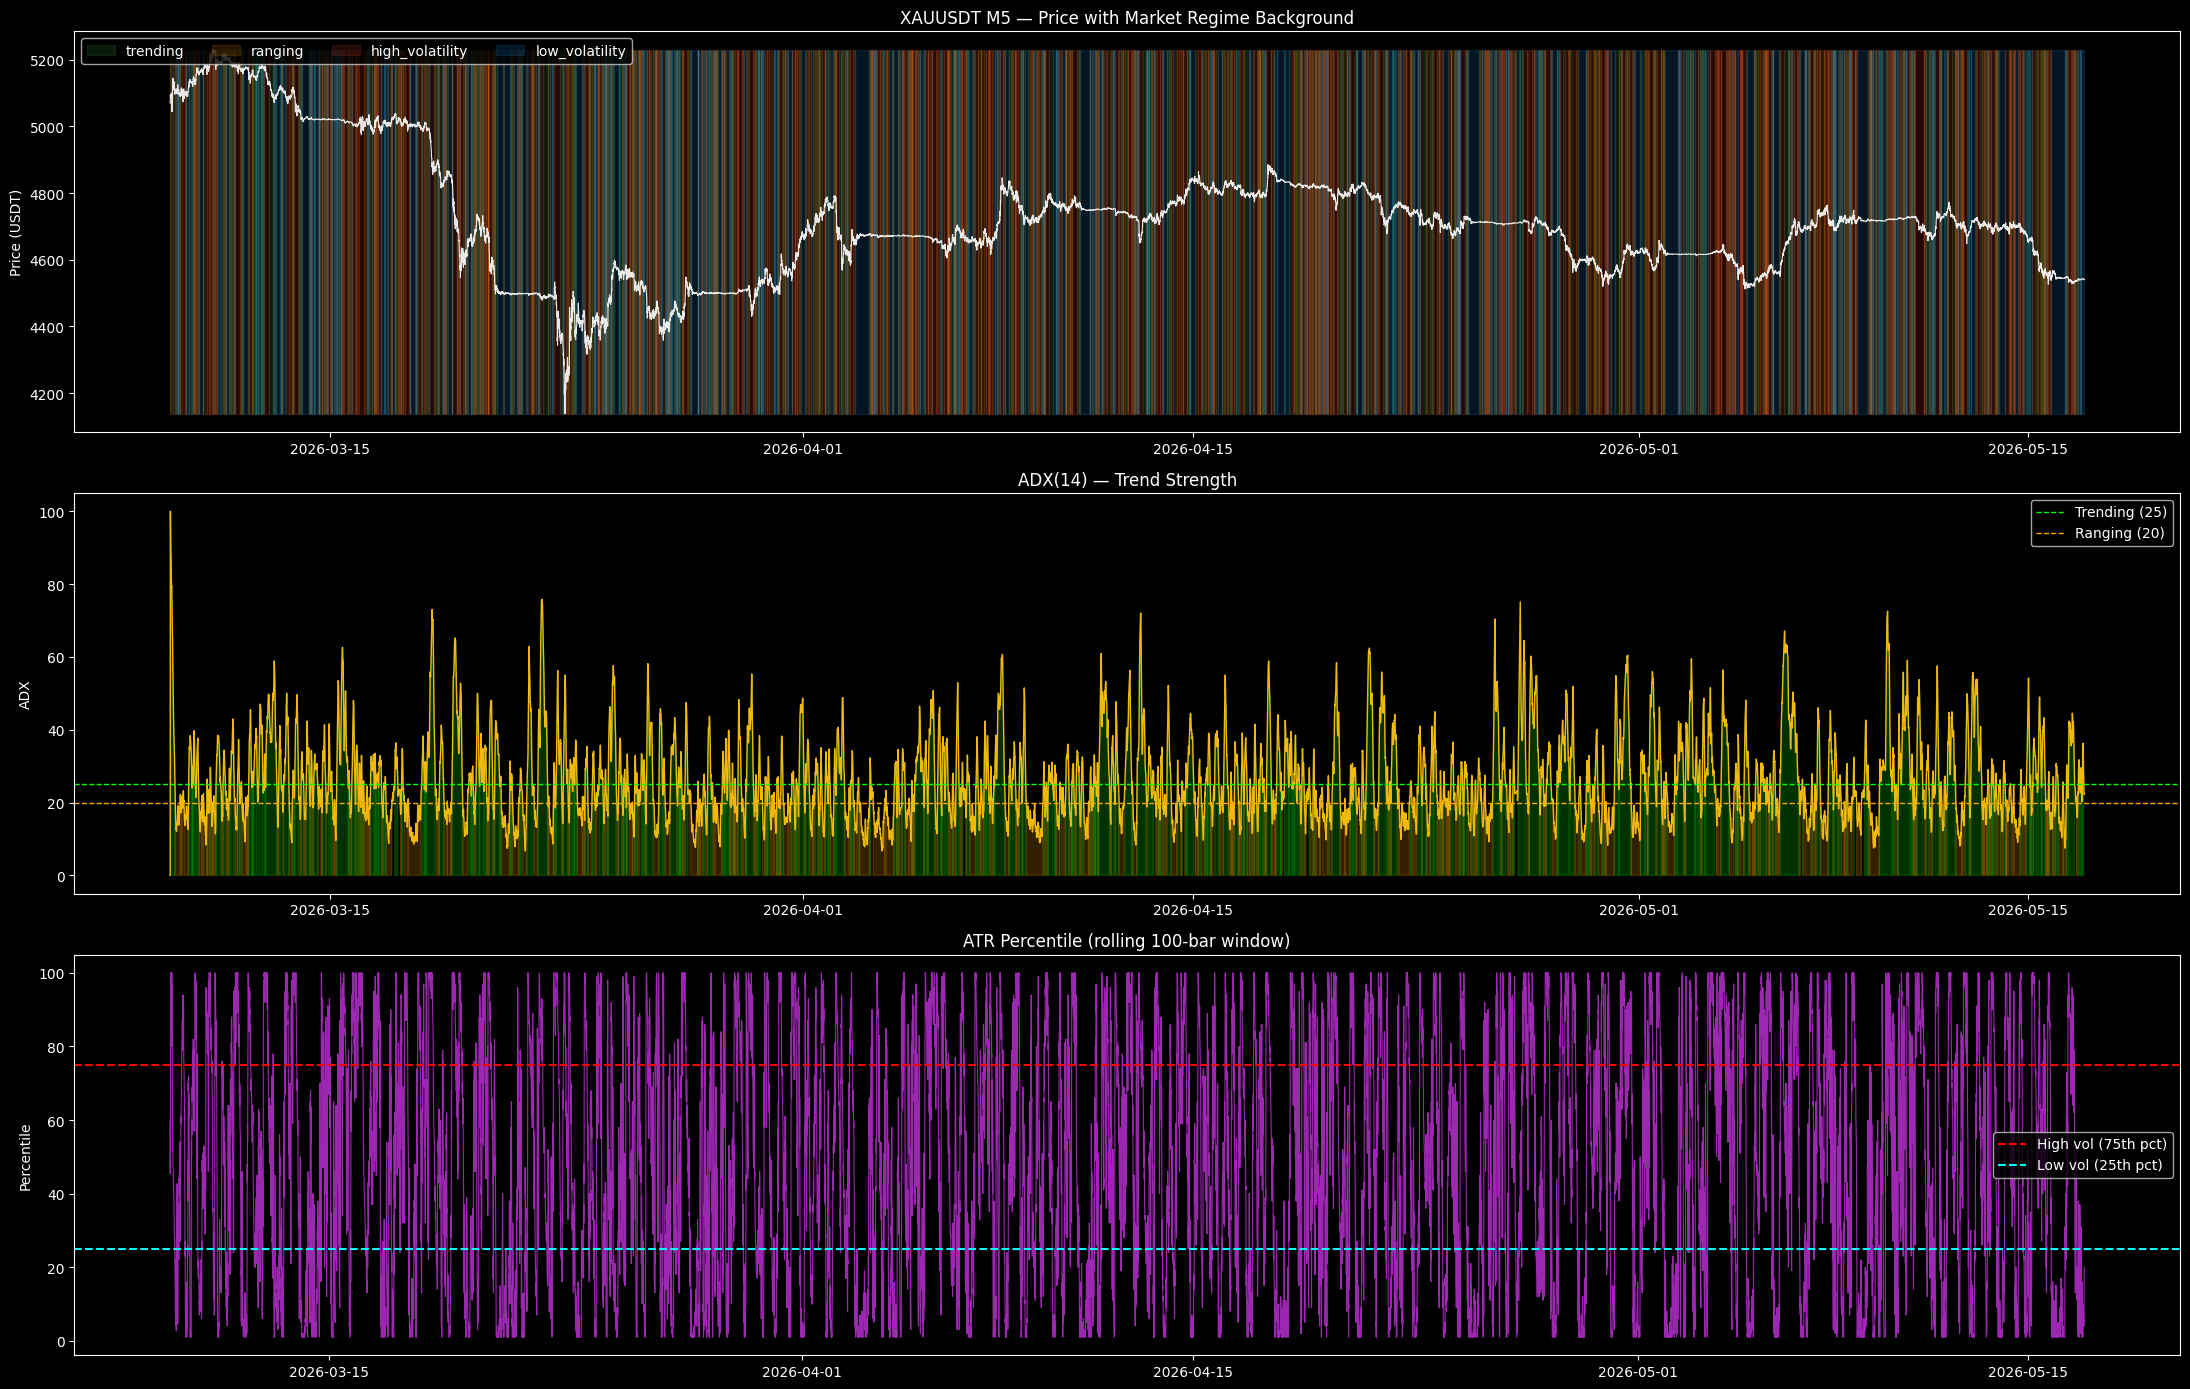

In [2]:
# ── Regime visualization ────────────────────────────────────────────────────
regime_colors = {
    'trending'       : '#4CAF50',
    'ranging'        : '#FF9800',
    'high_volatility': '#F44336',
    'low_volatility' : '#2196F3',
}

fig, axes = plt.subplots(3, 1, figsize=(22, 14))

# Price + regime background
ax = axes[0]
ax.plot(m5.index, m5['close'], color='white', linewidth=0.8, alpha=0.9)

for regime_val, color in regime_colors.items():
    mask = m5['regime'] == regime_val
    ax.fill_between(m5.index, m5['close'].min(), m5['close'].max(),
                    where=mask, alpha=0.15, color=color, label=regime_val)

ax.set_title(f'{SYMBOL} M5 — Price with Market Regime Background')
ax.legend(loc='upper left', ncol=4)
ax.set_ylabel('Price (USDT)')

# ADX
axes[1].plot(m5.index, m5['adx'], color='#F0B90B', linewidth=1.0)
axes[1].axhline(25, color='lime', linestyle='--', linewidth=1.0, label='Trending (25)')
axes[1].axhline(20, color='orange', linestyle='--', linewidth=1.0, label='Ranging (20)')
axes[1].fill_between(m5.index, 0, m5['adx'],
                     where=m5['adx'] >= 25, color='lime', alpha=0.2)
axes[1].fill_between(m5.index, 0, m5['adx'],
                     where=m5['adx'] <= 20, color='orange', alpha=0.2)
axes[1].set_title('ADX(14) — Trend Strength')
axes[1].set_ylabel('ADX')
axes[1].legend()

# ATR percentile
axes[2].plot(m5.index, m5['atr_percentile'], color='#9C27B0', linewidth=0.8)
axes[2].axhline(75, color='red',    linestyle='--', label='High vol (75th pct)')
axes[2].axhline(25, color='cyan',   linestyle='--', label='Low vol (25th pct)')
axes[2].set_title('ATR Percentile (rolling 100-bar window)')
axes[2].set_ylabel('Percentile')
axes[2].legend()

plt.tight_layout()
plt.show()

In [3]:
# ── OB performance by regime (theoretical) ─────────────────────────────────
# NOTE: A full regime-segmented backtest requires walking through the data
# bar-by-bar and tracking regime at signal time. This notebook shows the
# distribution of OB signals across regimes.

cfg_base   = OBSignalConfig(rr=2.0)
cfg_regime = OBSignalConfig(rr=2.0, regime_filter_enabled=True,
                            skip_ranging=True, adx_period=14)

sigs_base   = list_ob_signals_enhanced(m5, risk_cash=RISK, config=cfg_base)
sigs_regime = list_ob_signals_enhanced(m5, risk_cash=RISK, config=cfg_regime)
sigs_pass   = get_passed_signals(sigs_regime)

print(f'Baseline signals       : {len(sigs_base)}')
print(f'Regime-filtered (pass) : {len(sigs_pass)}')
pct = (1 - len(sigs_pass) / max(len(sigs_base), 1)) * 100
print(f'Reduction              : {pct:.1f}%')

# Current regime
current = detect_regime(m5)
print(f'\nCurrent market regime: {current.regime.value}')
print(f'  {current.description}')

Baseline signals       : 290
Regime-filtered (pass) : 290
Reduction              : 0.0%

Current market regime: low_volatility
  LOW VOLATILITY — ATR=0.42 at 20th pct (ADX=22.4). SL distances may be too small.
